importing all the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
!{sys.executable} -m pip install scikit-learn
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\ADMIN\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
df=pd.read_csv('telco.csv')

In [3]:
df.head(10)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,City,Zip Code,Latitude,Longitude,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,NaN,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
5,4412-YLTKF,Female,72,No,Yes,No,Yes,1,United States,California,Pico Rivera,90660,33.989524,-118.089299,63288,Q3,No,0,27,Offer C,Yes,3.33,Yes,Yes,Fiber Optic,18,No,No,Yes,No,No,No,No,No,Month-to-Month,Yes,Bank Withdrawal,78.05,2135.50,0.00,10,89.91,2235.41,1,Churned,Yes,95,4638,Competitor,Competitor had better devices
6,0390-DCFDQ,Female,76,No,Yes,Yes,Yes,2,United States,California,Los Alamitos,90720,33.794990,-118.065591,21343,Q3,Yes,1,1,Offer E,Yes,15.28,No,Yes,Fiber Optic,30,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Mailed Check,70.45,70.45,0.00,0,15.28,85.73,2,Churned,Yes,76,3964,Other,Don't know
7,3445-HXXGF,Male,66,No,Yes,Yes,No,0,United States,California,Sierra Madre,91024,34.168686,-118.057505,10558,Q3,Yes,6,58,Offer B,No,0.00,No,Yes,DSL,24,No,Yes,Yes,No,No,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,45.30,2651.20,40.95,0,0.00,2610.25,1,Churned,Yes,91,5444,Dissatisfaction,Service dissatisfaction
8,2656-FMOKZ,Female,70,No,Yes,No,Yes,2,United States,California,Pasadena,91106,34.139402,-118.128658,23742,Q3,No,0,15,Offer D,Yes,44.07,Yes,Yes,Fiber Optic,19,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Mailed Check,74.45,1145.70,0.00,0,661.05,1806.75,2,Churned,Yes,91,5717,Dissatisfaction,Limited range of services
9,2070-FNEXE,Female,77,No,Yes,No,Yes,2,United States,California,Pasadena,91107,34.159007,-118.087353,32369,Q3,No,0,7,Offer E,Yes,26.95,No,Yes,Fiber Optic,18,Yes,No,No,No,No,No,No,No,Month-to-Month,No,Bank Withdrawal,76.45,503.60,11.05,0,188.65,681.20,2,Churned,Yes,81,4419,Price,Lack of affordable download/upload speed


In [4]:
print(df.shape)

(7043, 50)


In [5]:
df.dtypes

Customer ID                           object
Gender                                object
Age                                    int64
Under 30                              object
Senior Citizen                        object
Married                               object
Dependents                            object
Number of Dependents                   int64
Country                               object
State                                 object
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple L

checking for missing values

In [6]:
print(df.isnull().sum())

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

treating missing values

In [7]:
df['Offer'] = df['Offer'].fillna('No Offer')

In [8]:
df['Internet Service'].value_counts()

Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

In [9]:
df['Internet Type'] = df['Internet Type'].fillna('No Internet')

In [10]:
df['Churn Category'] = df['Churn Category'].fillna('No churn')
df['Churn Reason'] = df['Churn Reason'].fillna('No churn')

No rows were dropped in place of an nan value no internet?churn was considered.

all these steps were done and are not necessary to run when resuming work.

In [11]:
#df.drop('Customer ID', axis=1, inplace=True)

In [12]:
#df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [13]:
#print('Churn Rate:', df['Churn Label'].mean().round(4) * 100, '%')

In [14]:
#df.to_csv(r'C:\Users\ADMIN\OneDrive\Desktop\project\churnanalysis\data\telco.csv', index=False)
#print('Cleaned data saved successfully.')

EDA

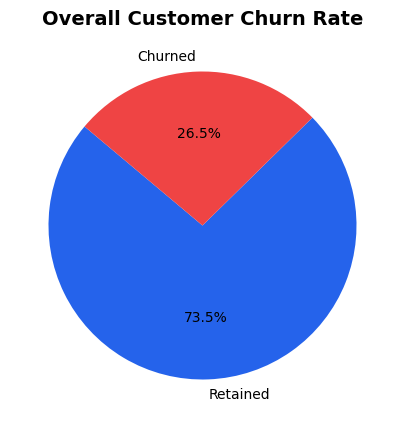

In [15]:
#What is the overall churn rate?
churn_counts = df['Churn Label'].value_counts()
plt.figure(figsize=(7,5))
plt.pie(churn_counts, labels=['Retained','Churned'], autopct='%1.1f%%', colors=['#2563EB','#EF4444'],
startangle=140)
plt.title('Overall Customer Churn Rate', fontsize=14, fontweight='bold')
plt.savefig('../images/01_overall_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df = pd.read_csv('telco.csv')

In [17]:
df['Churn Label'] = df['Churn Label'].str.strip()

df['Churn_Flag'] = df['Churn Label'].map({
    'Yes': 1,
    'No': 0
})

In [18]:
df['Churn_Flag'].isnull().sum()

np.int64(0)

In [19]:
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().reset_index()

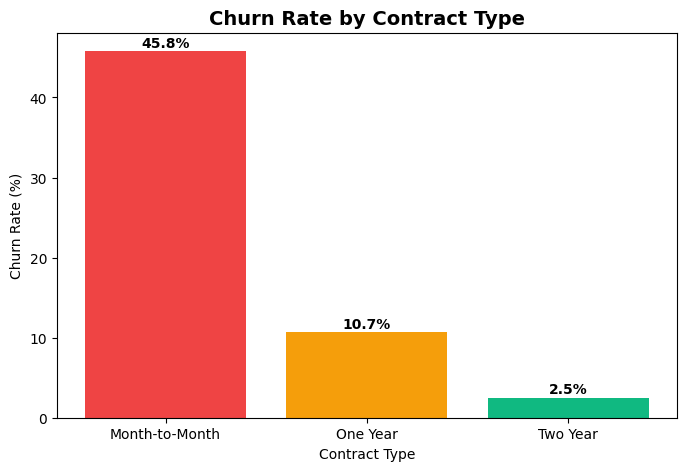

    Contract Type  Churn Rate  Churn Rate %
0  Month-to-Month    0.458449          45.8
1        One Year    0.107097          10.7
2        Two Year    0.025491           2.5

Highest churn contract type: Month-to-Month


In [20]:
# Which contract type has the highest churn?

# Group by Contract
contract_churn = df.groupby('Contract')['Churn_Flag'].mean().reset_index()

# Rename columns
contract_churn.columns = ['Contract Type', 'Churn Rate']

# Convert to percentage
contract_churn['Churn Rate %'] = (contract_churn['Churn Rate'] * 100).round(1)

# Sort for better visualization
contract_churn = contract_churn.sort_values(by='Churn Rate %', ascending=False)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(contract_churn['Contract Type'], contract_churn['Churn Rate %'],
               color=['#EF4444','#F59E0B','#10B981'])

# Title & labels
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')

# Add labels on bars
for bar, val in zip(bars, contract_churn['Churn Rate %']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center',
        fontweight='bold'
    )

# Save & show
plt.savefig('../images/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

# Print result
print(contract_churn)

# Answer (important for interview/exam)
print("\nHighest churn contract type:", contract_churn.iloc[0]['Contract Type'])

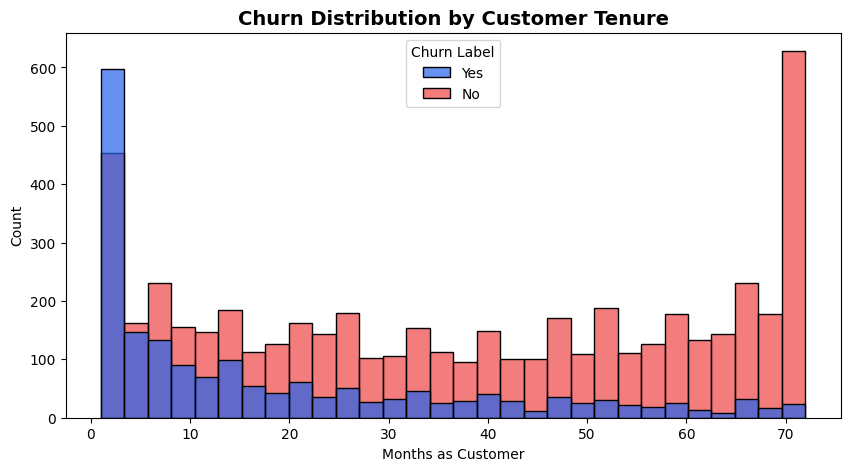

In [21]:
#Does tenure affect churn?
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Tenure in Months', hue='Churn Label', bins=30, palette=['#2563EB','#EF4444'], alpha=0.7)
plt.title('Churn Distribution by Customer Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Months as Customer')
plt.ylabel('Count')
plt.savefig('../images/03_churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

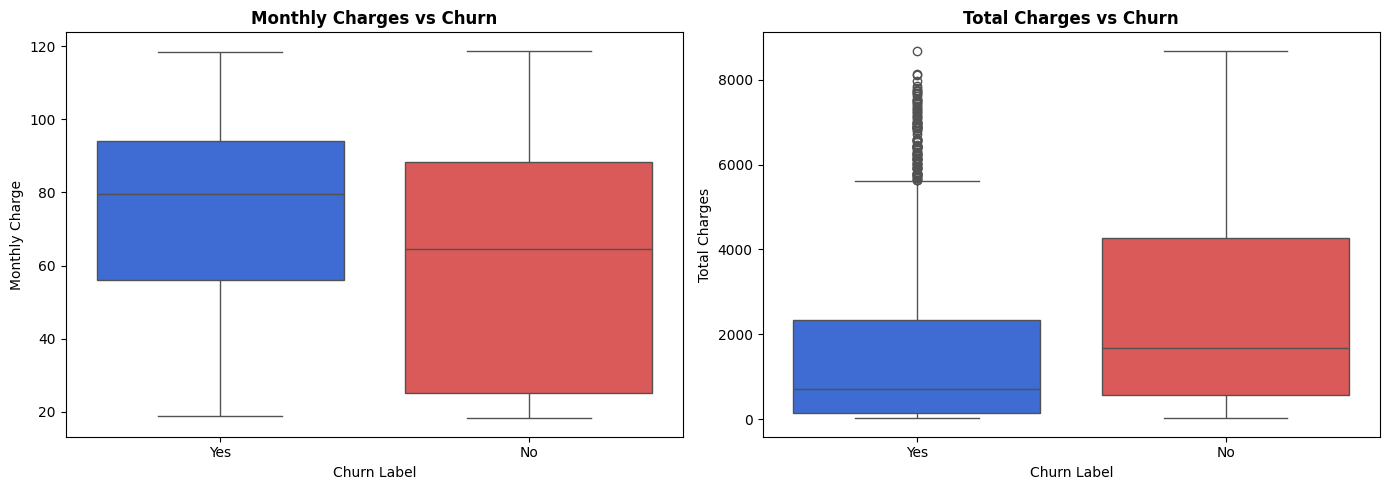

In [22]:
#Does monthly charge affect churn?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Churn Label', y='Monthly Charge', palette=['#2563EB','#EF4444'], ax=axes[0])
axes[0].set_title('Monthly Charges vs Churn', fontweight='bold')
sns.boxplot(data=df, x='Churn Label', y='Total Charges', palette=['#2563EB','#EF4444'], ax=axes[1])
axes[1].set_title('Total Charges vs Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/04_charges_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
#Which services do churned customers use?
service_cols = ['Phone Service','Internet Service','Online Security','Premium Tech Support','Streaming TV']
service_churn = {}
for col in service_cols:
    service_churn[col] = df.groupby(col)['Churn_Flag'].mean()
    print(df.groupby(col)['Churn_Flag'].mean().round(3) * 100)
    # Customers without OnlineSecurity churn significantly more — document thisprint('Churn rate by Online Security:')
print(df.groupby('Online Security')['Churn_Flag'].mean().round(3) * 100)

Phone Service
No     24.9
Yes    26.7
Name: Churn_Flag, dtype: float64
Internet Service
No      7.4
Yes    31.8
Name: Churn_Flag, dtype: float64
Online Security
No     31.3
Yes    14.6
Name: Churn_Flag, dtype: float64
Premium Tech Support
No     31.2
Yes    15.2
Name: Churn_Flag, dtype: float64
Streaming TV
No     24.3
Yes    30.1
Name: Churn_Flag, dtype: float64
Online Security
No     31.3
Yes    14.6
Name: Churn_Flag, dtype: float64


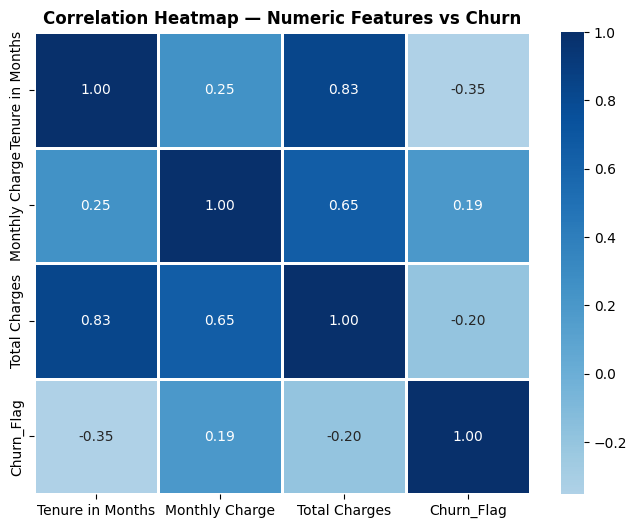

In [36]:
#Correlation Heatmap — what numerical factors are linked to churn?
numeric_cols = ['Tenure in Months', 'Monthly Charge', 'Total Charges', 'Churn_Flag']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f',cmap='Blues', center=0, linewidths=1)
plt.title('Correlation Heatmap — Numeric Features vs Churn', fontweight='bold')
plt.savefig('../images/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

KEY FINDINGS FROM EDA
1.OVERALL CHURN RATE IS: 26.5%.
2. Month-to-month customers churn at 45.8% vs 2.3% for two-year contracts.
3.Customers with tenure < 12 months are 3x more likely to churn.
4.Higher monthly charges (>$65) are correlated with churn.
5. Customers without OnlineSecurity and TechSupport churn at 2x the rate Business Recommendation: Offer discounts or free add-ons (security/support) to month-to-month customers in their first year to reduce churn.